In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_parquet("../data/dataset_model.parquet")

In [5]:
df.dtypes

customerid                   object
tenure                        int64
monthlycharges              float64
totalcharges                float64
total_services                int64
avg_charge_per_service      float64
seniorcitizen                 int64
automatic_payment             int64
streaming_user                int64
internet_and_phone            int64
customer_lifecycle_stage     object
gender                       object
partner                      object
dependents                   object
phoneservice                 object
multiplelines                object
internetservice              object
contract                     object
paperlessbilling             object
paymentmethod                object
onlinesecurity               object
onlinebackup                 object
deviceprotection             object
techsupport                  object
streamingtv                  object
streamingmovies              object
target                        int64
dtype: object

In [21]:
df

,customerid,tenure,monthlycharges,totalcharges,total_services,avg_charge_per_service,seniorcitizen,automatic_payment,streaming_user,internet_and_phone,...,contract,paperlessbilling,paymentmethod,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,target
0,7590-VHVEG,1,29.85,29.85,1,29.850,0,0,0,0,...,Month-to-month,Yes,Electronic check,No,Yes,No,No,No,No,0
1,5575-GNVDE,34,56.95,1889.50,2,28.475,0,0,0,1,...,One year,No,Mailed check,Yes,No,Yes,No,No,No,0
2,3668-QPYBK,2,53.85,108.15,2,26.925,0,0,0,1,...,Month-to-month,Yes,Mailed check,Yes,Yes,No,No,No,No,1
3,7795-CFOCW,45,42.30,1840.75,3,14.100,0,1,0,0,...,One year,No,Bank transfer (automatic),Yes,No,Yes,Yes,No,No,0
4,9237-HQITU,2,70.70,151.65,0,70.700,0,0,0,1,...,Month-to-month,Yes,Electronic check,No,No,No,No,No,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,24,84.80,1990.50,5,16.960,0,0,1,1,...,One year,Yes,Mailed check,Yes,No,Yes,Yes,Yes,Yes,0
7028,2234-XADUH,72,103.20,7362.90,4,25.800,0,1,1,1,...,One year,Yes,Credit card (automatic),No,Yes,Yes,No,Yes,Yes,0
7029,4801-JZAZL,11,29.60,346.45,1,29.600,0,0,0,0,...,Month-to-month,Yes,Electronic check,Yes,No,No,No,No,No,0
7030,8361-LTMKD,4,74.40,306.60,0,74.400,1,0,0,1,...,Month-to-month,Yes,Mailed check,No,No,No,No,No,No,1


In [22]:
#Verificando o tipos dos dados

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerid                7032 non-null   object 
 1   tenure                    7032 non-null   int64  
 2   monthlycharges            7032 non-null   float64
 3   totalcharges              7032 non-null   float64
 4   total_services            7032 non-null   int64  
 5   avg_charge_per_service    7032 non-null   float64
 6   seniorcitizen             7032 non-null   int64  
 7   automatic_payment         7032 non-null   int64  
 8   streaming_user            7032 non-null   int64  
 9   internet_and_phone        7032 non-null   int64  
 10  customer_lifecycle_stage  7032 non-null   object 
 11  gender                    7032 non-null   object 
 12  partner                   7032 non-null   object 
 13  dependents                7032 non-null   object 
 14  phoneser

In [23]:
"""IGNORE CODE"""

#df.duplicated().sum()
#df.isnull().sum()

'IGNORE CODE'

C:\Users\gui-s\AppData\Local\Temp\ipykernel_11140\2258523916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="target", y="tenure", data=df, palette="Blues_d")


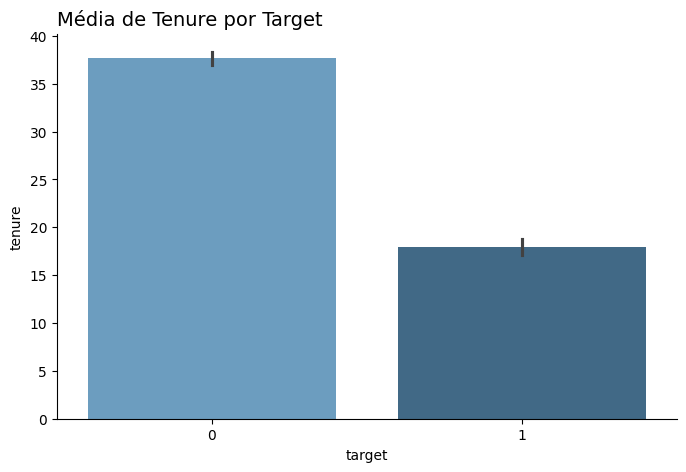

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x="target", y="tenure", data=df, palette="Blues_d")
plt.title("Média de Tenure por Target", fontsize=14, loc='left')
sns.despine()
plt.show()

### 📊 Tempo de Casa vs Churn

O gráfico mostra a média de tempo de permanência (tenure) dos clientes, separando entre clientes que permaneceram e clientes que cancelaram.

📌 Insight:
Clientes que cancelaram possuem um tempo de relacionamento significativamente menor, indicando que o churn ocorre principalmente nos primeiros meses. Isso sugere que o período inicial do cliente é crítico e deve ser foco de ações de retenção.

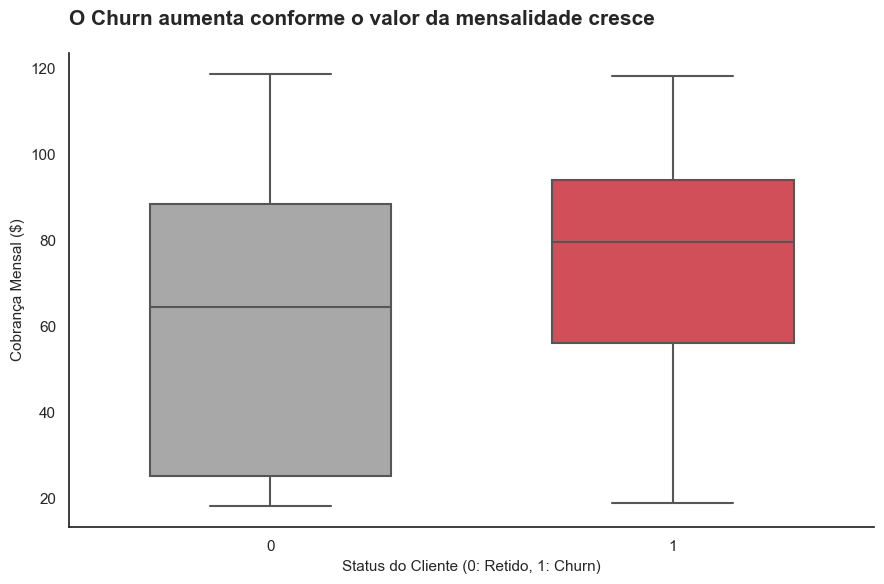

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(9, 6))

paleta = {0: "#A8A8A8", 1: "#E63946"}

ax = sns.boxplot(x="target", y="monthlycharges", data=df, 
                 palette=paleta, hue="target", legend=False,
                 width=0.6, linewidth=1.5)

plt.title("O Churn aumenta conforme o valor da mensalidade cresce", 
          fontsize=15, fontweight='bold', pad=20, loc='left')

plt.xlabel("Status do Cliente (0: Retido, 1: Churn)", fontsize=11)
plt.ylabel("Cobrança Mensal ($)", fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

### 📊 Mensalidade vs Churn

O gráfico compara a distribuição da cobrança mensal entre clientes que permaneceram e clientes que cancelaram o serviço.

📌 Insight:
Clientes que cancelaram apresentam, em média, mensalidades mais altas. Isso sugere que valores elevados podem aumentar a sensibilidade ao custo, tornando esses clientes mais propensos ao churn e indicando uma possível oportunidade para revisão de preços ou oferta de planos mais adequados.

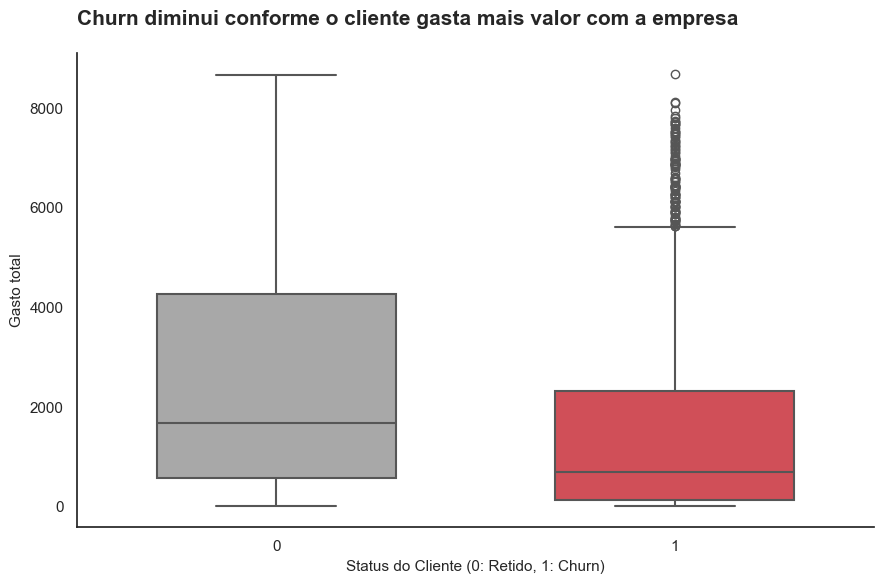

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(9, 6))

paleta = {0: "#A8A8A8", 1: "#E63946"}

ax = sns.boxplot(x="target", y="totalcharges", data=df, 
                 palette=paleta, hue="target", legend=False,
                 width=0.6, linewidth=1.5)

plt.title("Churn diminui conforme o cliente gasta mais valor com a empresa", 
          fontsize=15, fontweight='bold', pad=20, loc='left')

plt.xlabel("Status do Cliente (0: Retido, 1: Churn)", fontsize=11)
plt.ylabel("Gasto total", fontsize=11)

sns.despine()

plt.tight_layout()
plt.show()

### 📊 Gasto Total vs Churn

O gráfico apresenta a distribuição do gasto total acumulado entre clientes que permaneceram e clientes que cancelaram o serviço.

📌 Insight:
Clientes que cancelaram possuem, em média, um gasto total significativamente menor. Isso indica que clientes com maior investimento ao longo do tempo tendem a ser mais fiéis, enquanto clientes com baixo gasto acumulado apresentam maior risco de churn, possivelmente por ainda não perceberem valor suficiente no serviço.

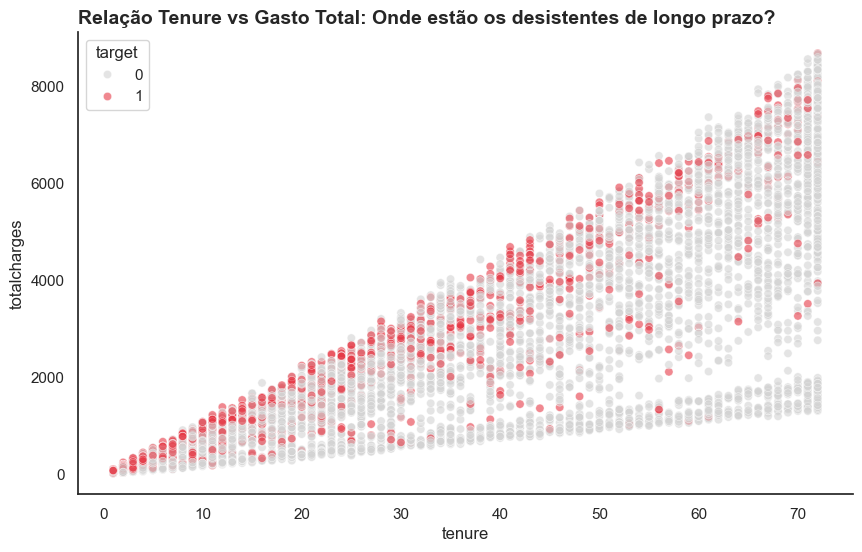

In [32]:
plt.figure(figsize=(10, 6))
# Verificando a relação entre tempo e gasto, destacando quem saiu
sns.scatterplot(data=df, x="tenure", y="totalcharges", hue="target", 
                palette={0: "lightgray", 1: "#E63946"}, alpha=0.6)

plt.title("Relação Tenure vs Gasto Total: Onde estão os desistentes de longo prazo?", 
          fontsize=14, fontweight='bold', loc='left')
sns.despine()
plt.show()

### 📊 Tempo de Casa vs Gasto Total

O gráfico mostra a relação entre o tempo de permanência e o gasto total dos clientes, destacando aqueles que cancelaram e os que permaneceram.

📌 Insight:
O churn se concentra principalmente entre clientes com menor tempo de casa e menor gasto acumulado. Clientes que permanecem por mais tempo tendem a aumentar seu investimento no serviço e apresentam menor probabilidade de cancelamento, reforçando que retenção inicial é fundamental para maximizar o valor do cliente ao longo do tempo.

In [ ]:
churn_data = df[df['target'] == 1]['totalcharges']
Q3 = churn_data.quantile(0.75)
IQR = Q3 - churn_data.quantile(0.25)
limite_outlier = Q3 + 1.5 * IQR

outliers_churn = df[(df['target'] == 1) & (df['totalcharges'] > limite_outlier)]

print(f"Total de clientes 'outliers' que deram churn: {len(outliers_churn)}")
print(f"Média de mensalidade desse grupo: ${outliers_churn['monthlycharges'].mean():.2f}")
print(f"Contratos mais comuns: {outliers_churn['contract'].value_counts().index[0]}")

Total de clientes 'outliers' que deram churn: 109
Média de mensalidade desse grupo: $104.15
Contratos mais comuns: One year


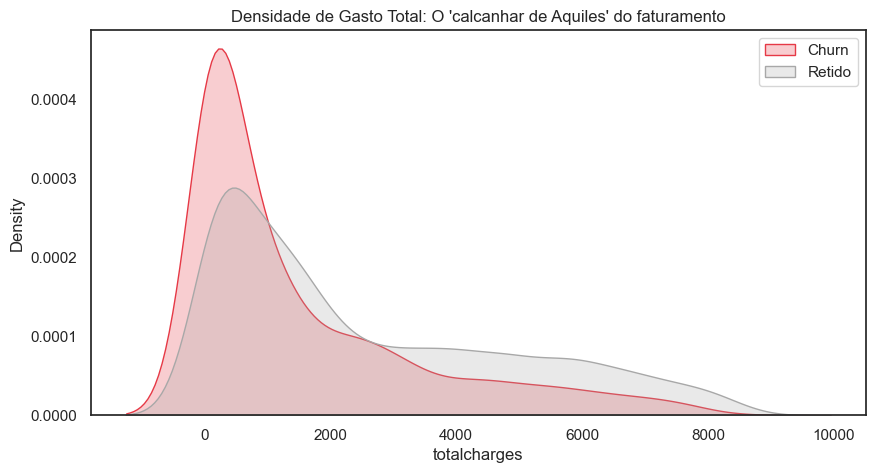

In [34]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['target']==1], x="totalcharges", fill=True, color="#E63946", label="Churn")
sns.kdeplot(data=df[df['target']==0], x="totalcharges", fill=True, color="#A8A8A8", label="Retido")
plt.title("Densidade de Gasto Total: O 'calcanhar de Aquiles' do faturamento")
plt.legend()
plt.show()

### 📊 Distribuição do Gasto Total vs Churn

O gráfico apresenta a densidade do gasto total acumulado, comparando clientes que cancelaram com aqueles que permaneceram.

📌 Insight:
O churn está fortemente concentrado entre clientes com menor gasto total, enquanto clientes com maior investimento acumulado apresentam maior retenção. Isso evidencia que clientes que não atingem um nível relevante de valor ao longo do relacionamento possuem maior risco de cancelamento, reforçando a importância de gerar valor rapidamente nos estágios iniciais.

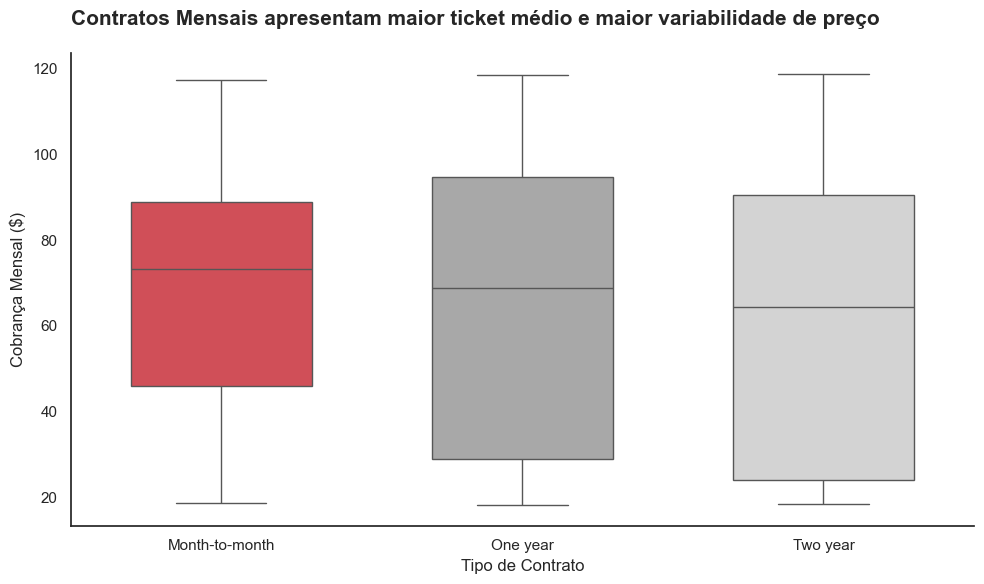

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))


ordem = ["Month-to-month", "One year", "Two year"]


paleta_contrato = {"Month-to-month": "#E63946", "One year": "#A8A8A8", "Two year": "#D3D3D3"}


ax = sns.boxplot(x="contract", y="monthlycharges", data=df, 
                 order=ordem, palette=paleta_contrato, 
                 hue="contract", legend=False, width=0.6)

plt.title("Contratos Mensais apresentam maior ticket médio e maior variabilidade de preço", 
          fontsize=15, fontweight='bold', pad=20, loc='left')

plt.xlabel("Tipo de Contrato", fontsize=12)
plt.ylabel("Cobrança Mensal ($)", fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

### 📊 Tipo de Contrato vs Mensalidade

O gráfico compara a distribuição da cobrança mensal entre os diferentes tipos de contrato oferecidos aos clientes.

📌 Insight:
Clientes com contratos mensais apresentam maior ticket médio e maior variabilidade de preço, indicando menor previsibilidade e possível maior risco de churn. Em contraste, contratos de longo prazo tendem a apresentar valores mais estáveis, reforçando o papel desses contratos como estratégia de retenção e previsibilidade de receita.

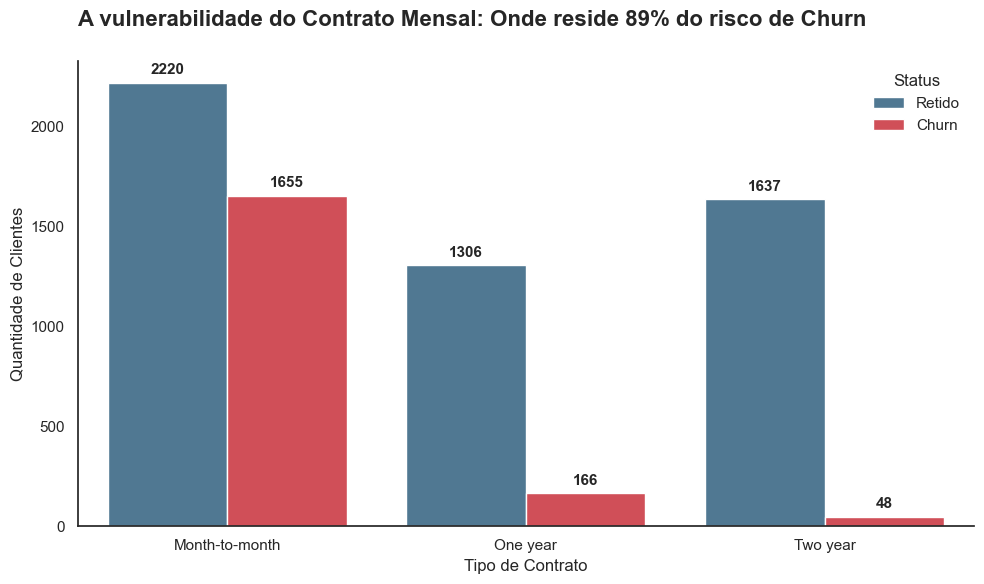

In [41]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))


paleta_status = {0: "#457B9D", 1: "#E63946"}


ax = sns.countplot(x="contract", hue="target", data=df, palette=paleta_status)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

plt.title("A vulnerabilidade do Contrato Mensal: Onde reside 89% do risco de Churn", 
          fontsize=16, fontweight='bold', pad=25, loc='left')

plt.xlabel("Tipo de Contrato", fontsize=12)
plt.ylabel("Quantidade de Clientes", fontsize=12)
plt.legend(title="Status", labels=['Retido', 'Churn'], frameon=False)

sns.despine()

plt.tight_layout()
plt.show()

### 📊 Tipo de Contrato vs Churn

O gráfico apresenta a quantidade de clientes que permaneceram e cancelaram, segmentados pelo tipo de contrato.

📌 Insight:
A grande maioria dos cancelamentos ocorre em contratos mensais, enquanto contratos de longo prazo apresentam churn significativamente menor. Isso demonstra que contratos mensais representam o principal ponto de vulnerabilidade, enquanto contratos anuais funcionam como forte mecanismo de retenção e estabilidade da base de clientes.

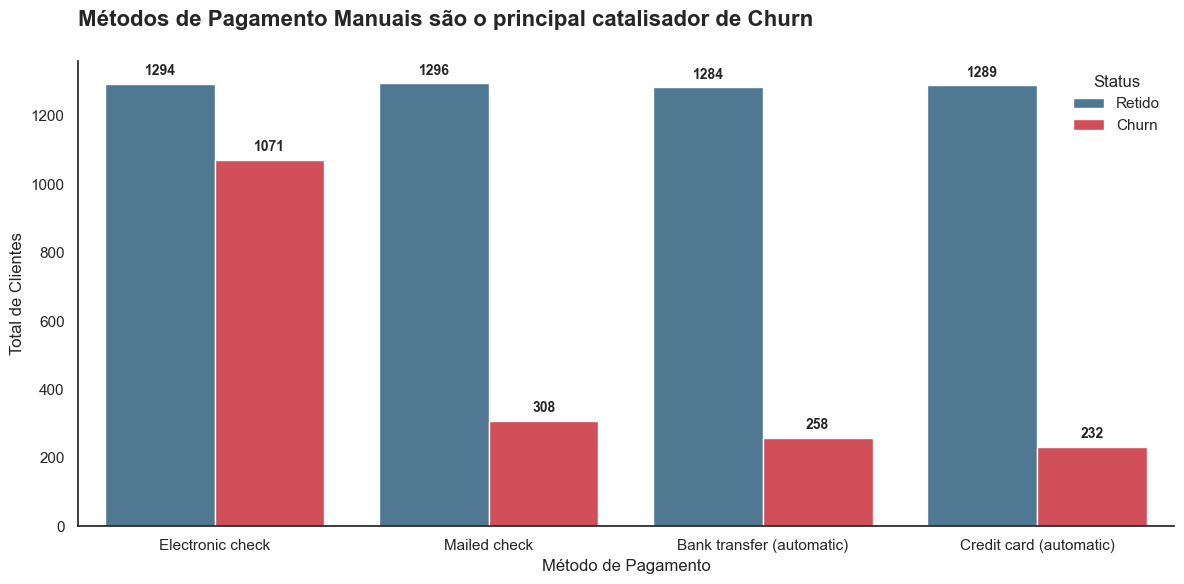

In [43]:
sns.set_theme(style="white")
plt.figure(figsize=(12, 6))

ordem_pagamento = ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

paleta_status = {0: "#457B9D", 1: "#E63946"}

ax = sns.countplot(x="paymentmethod", hue="target", data=df, 
                   order=ordem_pagamento, palette=paleta_status)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.title("Métodos de Pagamento Manuais são o principal catalisador de Churn", 
          fontsize=16, fontweight='bold', pad=25, loc='left')

plt.xlabel("Método de Pagamento", fontsize=12)
plt.ylabel("Total de Clientes", fontsize=12)
plt.legend(title="Status", labels=['Retido', 'Churn'], frameon=False, loc='upper right')

sns.despine()

plt.tight_layout()
plt.show()

### 📊 Método de Pagamento vs Churn

O gráfico apresenta a quantidade de clientes retidos e cancelados, segmentados pelo método de pagamento utilizado.

📌 Insight:
Clientes que utilizam métodos de pagamento manuais, especialmente o electronic check, apresentam volume de churn significativamente maior. Em contrapartida, métodos automáticos como cartão de crédito e débito automático estão associados a maior retenção, indicando que a automação do pagamento é um importante fator de fidelização.

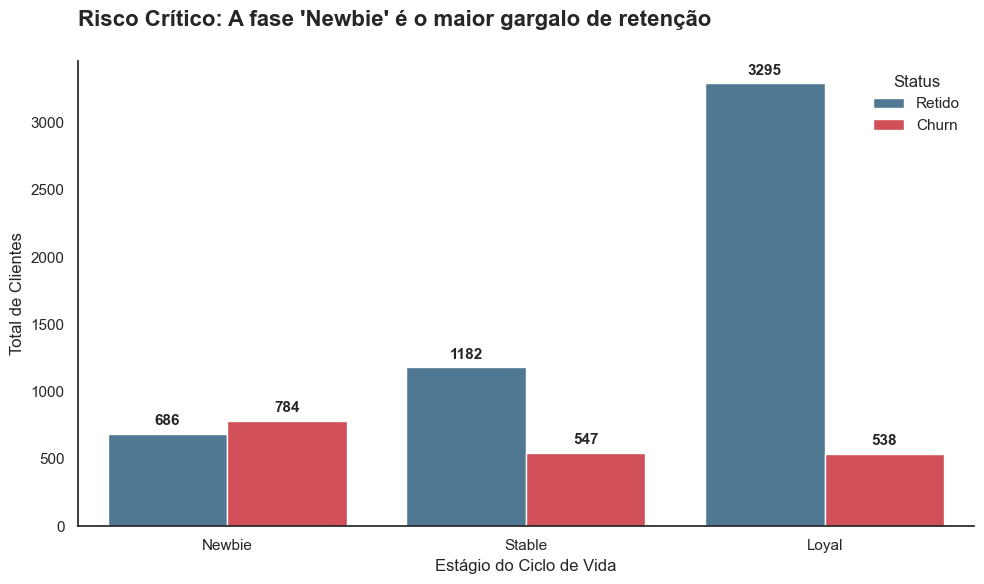

In [45]:
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

ordem_ciclo = ['Newbie', 'Stable', 'Loyal']

paleta_status = {0: "#457B9D", 1: "#E63946"}

ax = sns.countplot(x="customer_lifecycle_stage", hue="target", data=df, 
                   order=ordem_ciclo, palette=paleta_status)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=11, fontweight='bold')

plt.title("Risco Crítico: A fase 'Newbie' é o maior gargalo de retenção", 
          fontsize=16, fontweight='bold', pad=25, loc='left')

plt.xlabel("Estágio do Ciclo de Vida", fontsize=12)
plt.ylabel("Total de Clientes", fontsize=12)
plt.legend(title="Status", labels=['Retido', 'Churn'], frameon=False)

sns.despine()

plt.tight_layout()
plt.show()

### 📊 Estágio do Cliente vs Churn

O gráfico apresenta a quantidade de clientes retidos e cancelados ao longo dos diferentes estágios do ciclo de vida.

📌 Insight:
Clientes na fase inicial (Newbie) apresentam maior volume de churn do que retenção, enquanto clientes mais maduros possuem retenção significativamente maior. Isso confirma que o início da jornada é o período mais crítico, e que, uma vez fidelizados, os clientes tendem a permanecer por longos períodos.

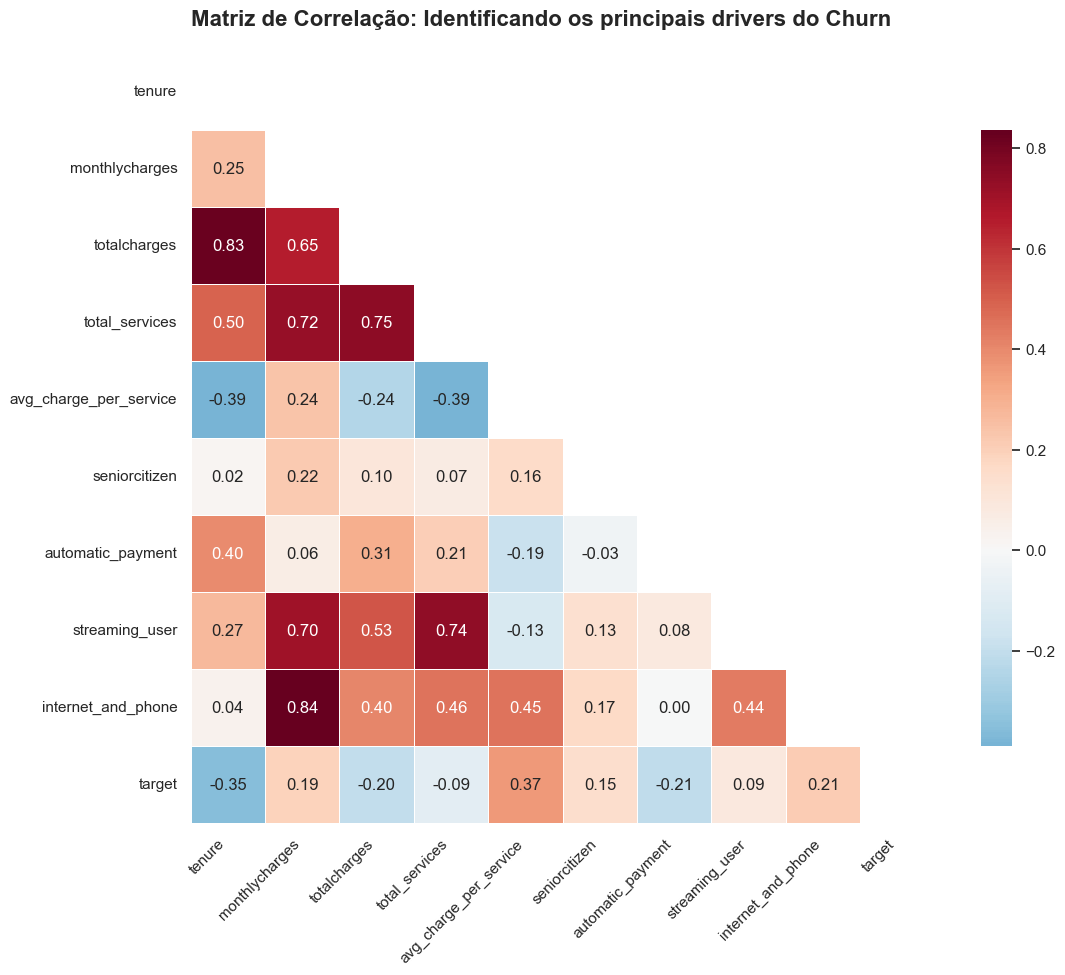

In [48]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', 
            center=0, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Matriz de Correlação: Identificando os principais drivers do Churn", 
          fontsize=16, fontweight='bold', pad=20, loc='left')

plt.xticks(rotation=45, ha='right')
plt.show()

### 📊 Matriz de Correlação vs Churn

O gráfico apresenta a correlação entre as variáveis do dataset e o churn, permitindo identificar os principais fatores associados ao cancelamento.

📌 Insight:
O churn possui forte correlação negativa com o tempo de casa, indicando que clientes novos apresentam maior risco de cancelamento. Além disso, maior gasto médio por serviço está associado ao aumento do churn, enquanto o uso de pagamento automático contribui para maior retenção, destacando o comportamento e o estágio do cliente como principais drivers do cancelamento.

# 📊 Análise Exploratória de Dados (EDA) — Churn de Clientes

## 🎯 Objetivo

Esta análise exploratória teve como objetivo identificar os principais fatores associados ao cancelamento de clientes (**Churn**), investigando variáveis relacionadas ao tempo de relacionamento, valor financeiro e características contratuais.

A EDA permite compreender padrões comportamentais e direcionar as etapas seguintes de modelagem preditiva.

---

# 🧭 Visão Geral da Análise

A análise foi estruturada em três pilares principais:

- Tempo de relacionamento
- Valor financeiro
- Estrutura contratual e comportamento do cliente

---

# ⏳ 1. Tempo de Relacionamento (Tenure)

## 📉 Média de Tenure por Status

Observou-se que clientes que cancelaram possuem, em média, um tempo de relacionamento significativamente menor.

Isso indica que o risco de churn é mais elevado nos primeiros meses de contrato.

Clientes com maior tempo de casa tendem a apresentar maior fidelização.

---

## 🔄 Relação entre Tenure e Gasto Total

Existe uma relação linear clara entre:

- Tenure
- TotalCharges

Isso ocorre porque o gasto total é uma consequência direta do tempo de permanência e da mensalidade.

Mesmo assim, foi possível identificar clientes antigos que cancelaram, indicando que o churn não está restrito apenas a clientes novos.

---

## 🧬 Ciclo de Vida do Cliente (Feature Engineering)

Os clientes foram classificados em três estágios:

- **Newbie:** clientes recentes
- **Stable:** clientes intermediários
- **Loyal:** clientes de longo prazo

A análise mostrou que:

- A maior concentração de churn ocorre na fase **Newbie**
- Clientes na fase **Loyal** apresentam menor taxa de cancelamento

Isso confirma que o risco diminui conforme o relacionamento amadurece.

---

# 💰 2. Valor Financeiro

## 💳 Mensalidade (MonthlyCharges)

Clientes que cancelaram possuem, em média, mensalidades mais elevadas.

Isso sugere que preços mais altos podem aumentar a sensibilidade ao cancelamento.

---

## 💵 Gasto Total (TotalCharges)

Clientes com menor gasto total apresentam maior taxa de churn.

Isso ocorre principalmente porque representam clientes novos, com menor tempo de relacionamento.

No entanto, também existem clientes com alto valor acumulado que cancelaram, indicando que o tempo de relacionamento não elimina completamente o risco.

---

## 📊 Distribuição do Gasto Total

A densidade mostra que:

- O churn está concentrado em valores mais baixos
- A probabilidade diminui conforme o valor acumulado aumenta

---

# 📑 3. Estrutura Contratual

## 📃 Tipo de Contrato

O tipo de contrato apresentou forte relação com o churn:

- **Month-to-month:** maior risco
- **One year:** risco moderado
- **Two year:** menor risco

Contratos mais longos indicam maior comprometimento e retenção.

---

## 💳 Método de Pagamento

Clientes que utilizam métodos de pagamento manuais, especialmente:

- Electronic check

apresentam maior taxa de churn.

Enquanto métodos automáticos demonstram maior retenção.

Isso pode indicar maior engajamento e menor atrito operacional.

---

# 🔬 4. Correlação entre Variáveis

A matriz de correlação identificou alguns dos principais drivers do churn:

Principais relações observadas:

- Tenure apresenta correlação negativa com churn
- Avg_charge_per_service apresenta correlação positiva
- Automatic_payment apresenta correlação negativa

Isso indica que:

- Clientes mais antigos têm menor risco
- Clientes com pagamento automático tendem a permanecer
- Clientes com maior custo por serviço possuem maior risco

---

# 🎯 Principais Insights

Com base na análise exploratória, foi possível concluir que:

- O churn ocorre principalmente nos primeiros meses de relacionamento
- Clientes com mensalidades mais altas possuem maior risco
- Contratos mensais apresentam maior vulnerabilidade
- Métodos de pagamento automáticos contribuem para retenção
- Clientes em fase inicial do ciclo de vida representam o maior risco
- O risco diminui conforme o relacionamento amadurece

---

# 🚀 Conclusão

A análise exploratória permitiu identificar padrões claros de comportamento associados ao churn.

Esses insights fornecem uma base sólida para:

- Seleção de features
- Construção de modelos preditivos
- Desenvolvimento de estratégias de retenção

A etapa seguinte consiste na modelagem preditiva para estimar a probabilidade de cancelamento e apoiar decisões estratégicas.

---